In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor

In [2]:
# считываем данные
data = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s15t2_apt_price_prediction.csv')

# выводим первые 5 строк таблицы и её описание
print(data.head())
print(data.describe())
print(data.info())

   area  floor  rooms_amount  house_year     location  condition  has_balcony  \
0  21.7      1             1        1970  city_center          5        False   
1  20.3      2             2        1958  city_center          5        False   
2  27.6      1             1        1938  city_center          4        False   
3  15.6      1             1        1902     suburban          3         True   
4  64.5      4             1        1975  city_center          3         True   

     price  
0  1.49919  
1  4.24998  
2  2.66746  
3  2.44020  
4  6.36056  
              area        floor  rooms_amount   house_year    condition  \
count  2000.000000  2000.000000   2000.000000  2000.000000  2000.000000   
mean     31.871650     1.635500      1.384000  1961.446000     3.488000   
std      17.372582     0.810536      0.568072    35.926695     1.126273   
min      14.000000     1.000000      1.000000  1900.000000     2.000000   
25%      19.000000     1.000000      1.000000  1930.000000  

In [3]:
# разделяем признаки и целевую переменную
X = data.drop(columns=['price'])
y = data['price']

In [4]:
# определяем категориальные и числовые признаки
categorical_features = data.select_dtypes(include=['string', 'object']).columns.to_list()
numeric_features = [col for col in X.columns if col not in categorical_features]

In [5]:
# создаём препроцессор для категориальных и числовых данных
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

In [6]:
# делим на трейн и тест
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# проверяем количество наблюдений в train и test
print(f"Количество наблюдений в train: {len(X_train)}")
print(f"Количество наблюдений в test: {len(X_test)}")

Количество наблюдений в train: 1500
Количество наблюдений в test: 500


### Эксперимент

In [7]:
# создаём пустые массивы для предсказаний
predictions_shallow_tree, predictions_deep_tree, predictions_bagging = [], [], []

In [8]:
# создайте пайплайн - неглубокое дерево с глубиной 2
shallow_tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=2, random_state=42))
])

# создайте пайплайн - глубокое дерево с глубиной 10
deep_tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=10, random_state=42))
])

# создайте пайплайн - бэггинг с параметрами: estimator = решающее дерево с глубиной 10,
# boostrap = True, random_state = 42, n_jobs = 1
bagging_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=10, random_state=42),
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ))
])

In [9]:
# создаём цикл бутстрапа на 10 подвыборок
for _ in range(10):
    indices = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_bootstrap, y_bootstrap = X_train.iloc[indices], y_train.iloc[indices]

    # обучите все три выше созданных пайплайна
    shallow_tree_pipeline.fit(X_bootstrap, y_bootstrap)
    deep_tree_pipeline.fit(X_bootstrap, y_bootstrap)
    bagging_pipeline.fit(X_bootstrap, y_bootstrap)

    # получите предсказания моделей на тестовой выборке
    pred_shallow = shallow_tree_pipeline.predict(X_test)
    pred_deep = deep_tree_pipeline.predict(X_test)
    pred_bagging = bagging_pipeline.predict(X_test)

    # сохраните предсказания в созданные массивы
    predictions_shallow_tree.append(pred_shallow)
    predictions_deep_tree.append(pred_deep)
    predictions_bagging.append(pred_bagging)

In [10]:
# преобразуем массивы в numpy.array для корректного расчёта bias и variance
predictions_shallow_tree = np.array(predictions_shallow_tree)
predictions_deep_tree = np.array(predictions_deep_tree)
predictions_bagging = np.array(predictions_bagging)

# рассчитайте bias и variance
bias_shallow = np.mean((y_test - np.mean(predictions_shallow_tree, axis=0))**2)
bias_deep = np.mean((y_test - np.mean(predictions_deep_tree, axis=0))**2)
bias_bagging = np.mean((y_test - np.mean(predictions_bagging, axis=0))**2)

variance_shallow = np.mean(np.var(predictions_shallow_tree, axis=0))
variance_deep = np.mean(np.var(predictions_deep_tree, axis=0))
variance_bagging = np.mean(np.var(predictions_bagging, axis=0))

# выводим полученные значения. Округляем вывод до 4 знаков при помощи форматирования f-строк
print(f"Неглубокое дерево | Bias: {bias_shallow:.4f} | Variance: {variance_shallow:.4f}")
print(f"Глубокое дерево | Bias: {bias_deep:.4f} | Variance: {variance_deep:.4f}")
print(f"Бэггинг | Bias: {bias_bagging:.4f} | Variance: {variance_bagging:.4f}")

Неглубокое дерево | Bias: 4.8527 | Variance: 0.2761
Глубокое дерево | Bias: 4.1854 | Variance: 2.1430
Бэггинг | Bias: 3.9037 | Variance: 0.5111


### Визуализация: графики bias и variance для бэггинга

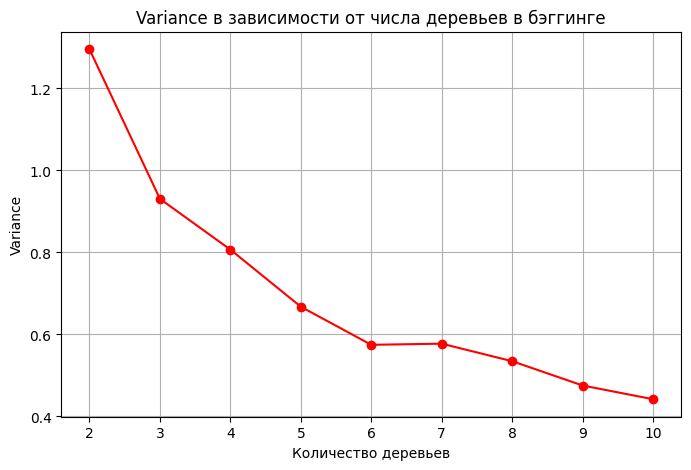

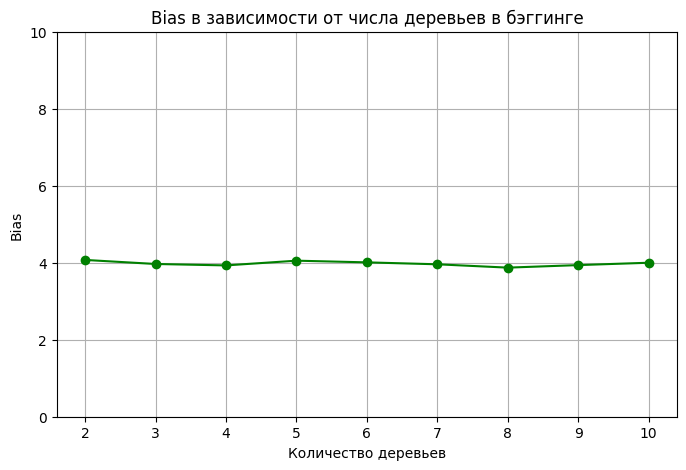

In [11]:
# графики зависимости bias и variance от числа глубоких деревьев в бэггинге
tree_counts = range(2, 11)
variances, biases = [], []

for n in tree_counts: # на каждом шаге строим новый бэггинг с изменённым количеством деревьев
    predictions = []
    for _ in range(10):
        indices = np.random.choice(np.arange(len(X_train)), size=len(X_train), replace=True)
        X_boost, y_boost = X_train.iloc[indices], y_train.iloc[indices]

        bagging_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', BaggingRegressor(
            estimator=DecisionTreeRegressor(max_depth=10),
            n_estimators=n,
            bootstrap=True,
            random_state=42,
            n_jobs=1
            ))
        ]).fit(X_boost, y_boost)
        predictions.append(bagging_pipeline.predict(X_test))  # сохраняем предсказания в массив
    predictions = np.array(predictions)
    variances.append(np.mean(np.var(predictions, axis=0)))  # считаем variance и сохраняем
    biases.append(np.mean((y_test - np.mean(predictions, axis=0)) ** 2))

# строим график variance
plt.figure(figsize=(8, 5))
plt.plot(tree_counts, variances, marker="o", color="red")
plt.title("Variance в зависимости от числа деревьев в бэггинге")
plt.xlabel("Количество деревьев")
plt.ylabel("Variance")
plt.grid(True)
plt.show()

# строим график bias
plt.figure(figsize=(8, 5))
plt.plot(tree_counts, biases, marker="o", color="green")
plt.title("Bias в зависимости от числа деревьев в бэггинге")
plt.xlabel("Количество деревьев")
plt.ylabel("Bias")
plt.ylim(bottom=0, top=10)
plt.grid(True)
plt.show()

### Визуализация границ решений

In [ ]:
# создаём 3 модели: неглубокое дерево, глубокое дерево, бэггинг - и обучаем на всей train-выборке
shallow_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(max_depth=2, random_state=42))
]).fit(X_train, y_train)

deep_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(max_depth=10, random_state=42))
]).fit(X_train, y_train)

bagging = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=10),
        bootstrap=True,
        random_state=42,
        n_jobs=1
    ))
]).fit(X_train, y_train)

# предсказания моделей
pred_shallow = shallow_tree.predict(X_test)
pred_deep = deep_tree.predict(X_test)
pred_bagging = np.array(bagging.predict(X_test))

# строим график
plt.figure(figsize=(20, 8))
plt.scatter(X_test["area"], y_test, color="gray")        # истинные значения - серые точки
plt.scatter(X_test["area"], pred_shallow, color="red")   # предсказания неглубокого дерева - красные точки
plt.scatter(X_test["area"], pred_deep, color="green")    # предсказания глубокого дерева - зелёные точки
plt.scatter(X_test["area"], pred_bagging, color="blue")  # предсказания бэггинга - синие точки

plt.title("Распределение значений цены в зависимости от площади квартиры")
plt.xlabel("Площадь квартиры, м2")
plt.ylabel("Цена, млн руб.")
plt.grid(True)

plt.tight_layout()
plt.show()

### Визуализация границ решений

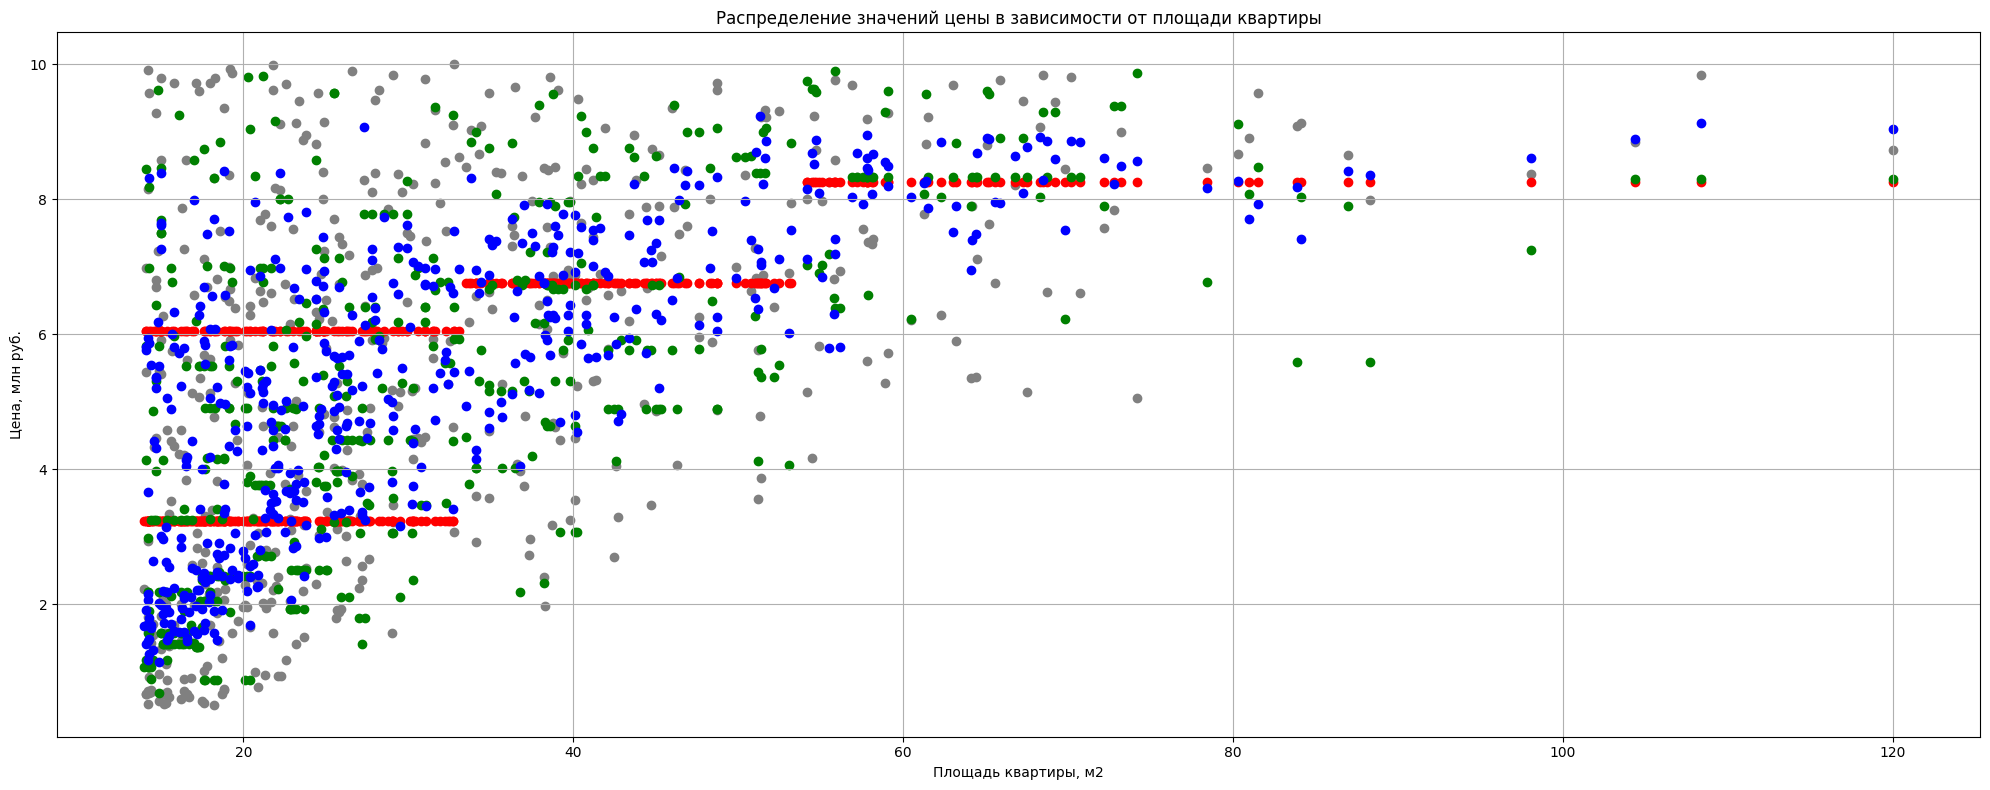

In [16]:
# создаём 3 модели: неглубокое дерево, глубокое дерево, бэггинг - и обучаем на всей train-выборке
shallow_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(max_depth=2, random_state=42))
]).fit(X_train, y_train)

deep_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(max_depth=10, random_state=42))
]).fit(X_train, y_train)

bagging = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=10),
        bootstrap=True,
        random_state=42,
        n_jobs=1
    ))
]).fit(X_train, y_train)

# предсказания моделей
pred_shallow = shallow_tree.predict(X_test)
pred_deep = deep_tree.predict(X_test)
pred_bagging = np.array(bagging.predict(X_test))

# строим график
plt.figure(figsize=(20, 8))
plt.scatter(X_test["area"], y_test, color="gray")        # истинные значения - серые точки
plt.scatter(X_test["area"], pred_shallow, color="red")   # предсказания неглубокого дерева - красные точки
plt.scatter(X_test["area"], pred_deep, color="green")    # предсказания глубокого дерева - зелёные точки
plt.scatter(X_test["area"], pred_bagging, color="blue")  # предсказания бэггинга - синие точки

plt.title("Распределение значений цены в зависимости от площади квартиры")
plt.xlabel("Площадь квартиры, м2")
plt.ylabel("Цена, млн руб.")
plt.grid(True)

plt.tight_layout()
plt.show()